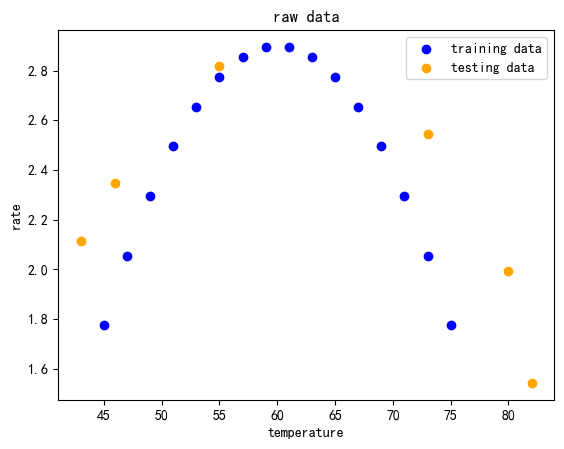

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置随机种子（保证结果可复现）
np.random.seed(42)

# 生成温度序列：45到75，步长2
temp_train = np.arange(45, 76, 2)  

# 用二次函数模拟rate的单峰趋势：rate = -0.005*(temp-60)^2 + 2.9
rate_train = -0.005 * (temp_train - 60) ** 2 + 2.9  

# 添加随机噪声
#noise_train = np.random.normal(0, 0.05, size=len(temp_train))
#rate_train += noise_train

# 保存为DataFrame并导出为CSV
train_df = pd.DataFrame({
    'temperature': temp_train,
    'rate': rate_train
})
train_df.to_csv('T-R-train.csv', index=False)

# 测试数据的温度点（覆盖低、中、高区间，匹配图中橙色点分布）
temp_test = np.array([43, 46, 55, 73, 80, 82])  

# 对应的rate（低/高温时rate低，中温接近训练峰值）
rate_test = np.array([2.1, 2.35, 2.8, 2.5, 2.0, 1.55])  

# 添加随机噪声
noise_test = np.random.normal(0, 0.03, size=len(temp_test))
rate_test += noise_test

# 保存为DataFrame并导出为CSV
test_df = pd.DataFrame({
    'temperature': temp_test,
    'rate': rate_test
})
test_df.to_csv('T-R-test.csv', index=False)

plt.scatter(train_df['temperature'], train_df['rate'], c='blue', label='training data')
plt.scatter(test_df['temperature'], test_df['rate'], c='orange', label='testing data')
plt.xlabel('temperature')
plt.ylabel('rate')
plt.title('raw data')
plt.legend()
plt.show()

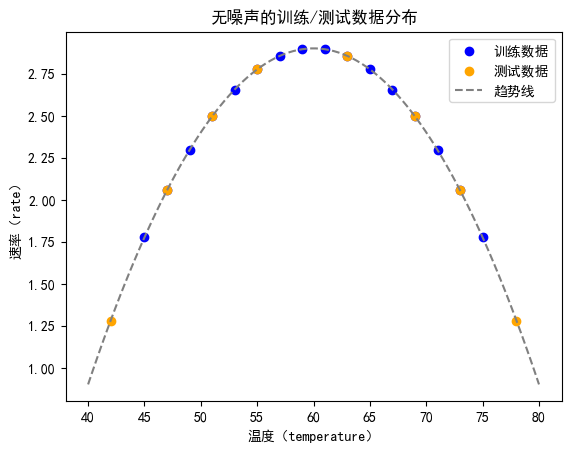

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置随机种子（本次无噪声，主要用于保持代码一致性）
np.random.seed(42)


# 1. 生成训练数据集（T-R-train.csv）：无噪声，严格遵循二次函数
temp_train = np.arange(45, 76, 2)  # 温度范围：45~75，步长2
# 单峰趋势函数（峰值在60℃左右）
rate_train = -0.005 * (temp_train - 60) ** 2 + 2.9  # 无噪声
train_df = pd.DataFrame({'temperature': temp_train, 'rate': rate_train})
train_df.to_csv('T-R-train.csv', index=False)


# 2. 生成测试数据集（T-R-test.csv）：无噪声，与训练集同趋势
# 测试温度点：贴近训练集范围（42~78），覆盖训练集未包含的中间点和边缘点
temp_test = np.array([42, 47, 51, 55, 63, 69, 73, 78])  
# 完全遵循训练集的二次函数（无噪声，保证趋势一致）
rate_test = -0.005 * (temp_test - 60) ** 2 + 2.9  
test_df = pd.DataFrame({'temperature': temp_test, 'rate': rate_test})
test_df.to_csv('T-R-test.csv', index=False)


# 3. 可视化验证（无噪声，数据点严格落在线上）
plt.scatter(train_df['temperature'], train_df['rate'], c='blue', label='训练数据')
plt.scatter(test_df['temperature'], test_df['rate'], c='orange', label='测试数据')
# 绘制趋势线（验证所有点均在同一线上）
x_trend = np.linspace(40, 80, 100)
y_trend = -0.005 * (x_trend - 60) ** 2 + 2.9
plt.plot(x_trend, y_trend, 'gray', linestyle='--', label='趋势线')
plt.xlabel('温度（temperature）')
plt.ylabel('速率（rate）')
plt.title('无噪声的训练/测试数据分布')
plt.legend()
plt.show()

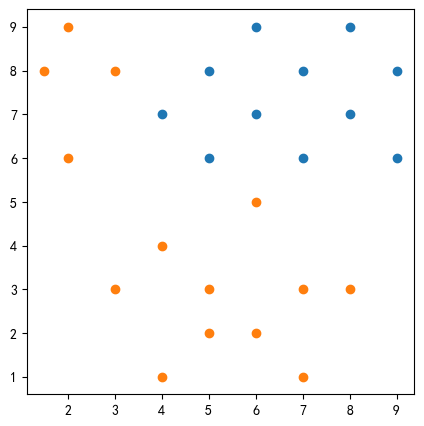

In [1]:
import pandas as pd

# 1. 模拟「good」类的坐标（橙色叉）
good_data = {
    "X1": [4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9],
    "X2": [7, 8, 6, 9, 7, 8, 6, 7, 9, 8, 6],
    "label": "good"
}

# 2. 模拟「bad」类的坐标（蓝色点）
bad_data = {
    "X1": [1.5, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8],
    "X2": [8, 9, 6, 8, 3, 4, 1, 3, 2, 5, 2, 3, 1, 3],
    "label": "bad"
}

# 3. 转换为 DataFrame 并合并
df_good = pd.DataFrame(good_data)
df_bad = pd.DataFrame(bad_data)
df = pd.concat([df_good, df_bad], ignore_index=True)

# 4. 保存为 CSV 文件
df.to_csv("raw_data.csv", index=False)

%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure(figsize=(5,5))
plt.scatter(df_good.loc[:,'X1'],df_good.loc[:,'X2'])
plt.scatter(df_bad.loc[:,'X1'],df_bad.loc[:,'X2'])
plt.show()

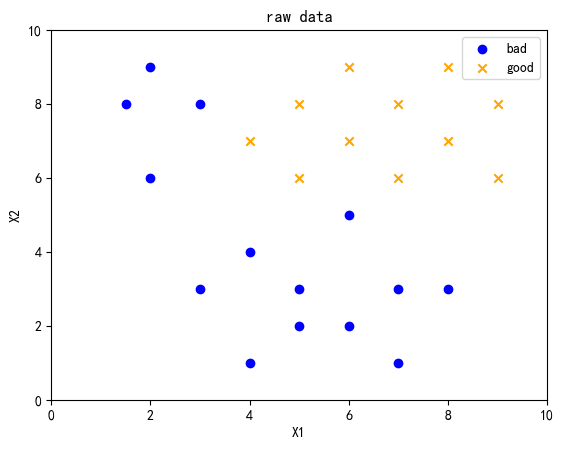

In [2]:
import pandas as pd

# 蓝色圆点（bad类）的坐标 (X1, X2)
bad_points = [
    (1.5, 8),
    (2, 9),
    (2, 6),
    (3, 8),
    (3, 3),
    (4, 1),
    (4, 4),
    (5, 2),
    (5, 3),
    (6, 5),
    (6, 2),
    (7, 3),
    (7, 1),
    (8, 3)
]

# 橙色叉（good类）的坐标 (X1, X2)
good_points = [
    (4, 7),
    (5, 6),
    (5, 8),
    (6, 7),
    (6, 9),
    (7, 6),
    (7, 8),
    (8, 7),
    (8, 9),
    (9, 6),
    (9, 8)
]

# 构造DataFrame
bad_df = pd.DataFrame(bad_points, columns=["X1", "X2"])
bad_df["label"] = "bad"

good_df = pd.DataFrame(good_points, columns=["X1", "X2"])
good_df["label"] = "good"

# 合并两类数据
final_df = pd.concat([bad_df, good_df], ignore_index=True)

# 保存为CSV
final_df.to_csv("raw_data_exact.csv", index=False)

import matplotlib.pyplot as plt

# 读取生成的CSV
df = pd.read_csv("raw_data_exact.csv")

# 分离两类点
bad = df[df["label"] == "bad"]
good = df[df["label"] == "good"]

# 绘图
plt.scatter(bad["X1"], bad["X2"], color="blue", label="bad")
plt.scatter(good["X1"], good["X2"], marker="x", color="orange", label="good")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("raw data")
plt.legend()
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.show()